In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math as mt
from scipy.stats import norm

In [2]:
mu, sigma = 0, 2 # mean and standard deviation
sample = np.random.normal(mu, sigma, 100000)
grid = np.linspace(-3*sigma, 3*sigma, 1000)

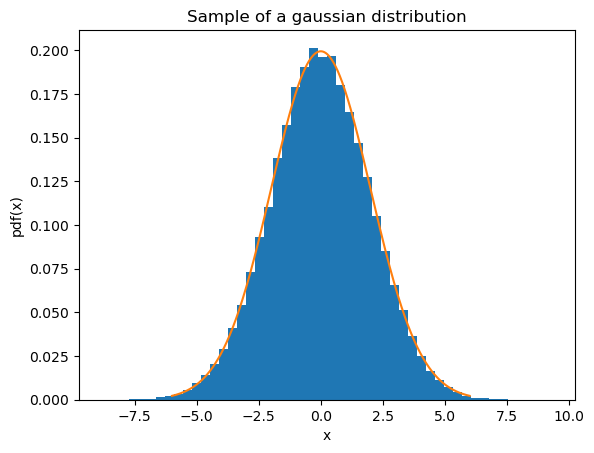

In [3]:
plt.hist(sample, bins=50, density=True)
plt.plot(grid, norm.pdf(grid, mu, sigma))
plt.title("Sample of a gaussian distribution")
plt.xlabel("x")
plt.ylabel("pdf(x)")
plt.show()

In [4]:
def f(x):
    return x**3

In [5]:
# let's compute the normalization of the pdf used for the integral
N = 0.5*np.sqrt(2*np.pi)*sigma

In [6]:
# let's apply the Monte Carlo integration theorem
montecarlo = np.mean(f(np.abs(sample)))
result = N*montecarlo
known_result= 2*sigma**4 

print("observed I = {:.3f}".format(result))
print("expected I = {:.3f}".format(known_result))
print("error on I = {:.3f}".format(np.abs(result-known_result)/known_result))

observed I = 32.083
expected I = 32.000
error on I = 0.003


In [7]:
vec_result = []
vec_error = []
for pop in np.logspace(1, 6, 1000, dtype=int):
    sample = np.random.normal(mu, sigma, pop)
    montecarlo = np.mean(f(np.abs(sample)))
    result = N*montecarlo
    vec_result.append(result)
    vec_error.append(np.abs(result-known_result)/known_result)

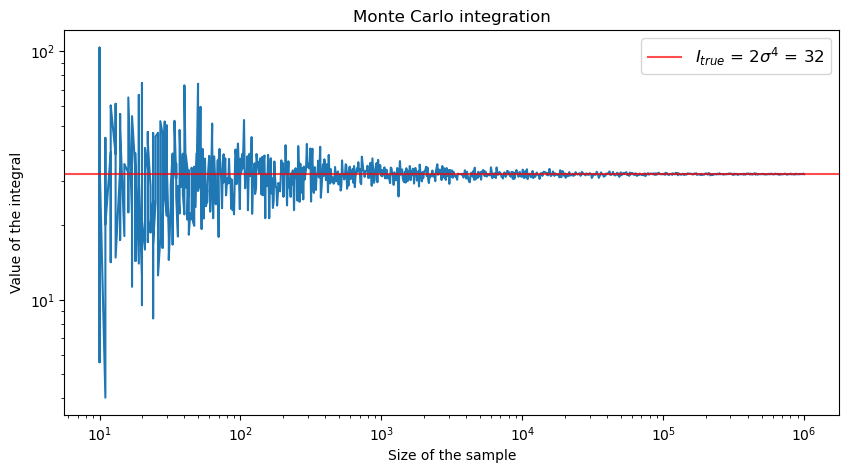

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(np.logspace(1, 6, 1000, dtype=int), vec_result)
plt.axhline(y=known_result, color='red', alpha=0.7, label="$I_{true}$ = $2 \sigma ^4$ = 32")
plt.title("Monte Carlo integration")
plt.xlabel("Size of the sample")
plt.ylabel("Value of the integral")
plt.loglog()
plt.legend(fontsize=12)
plt.show()

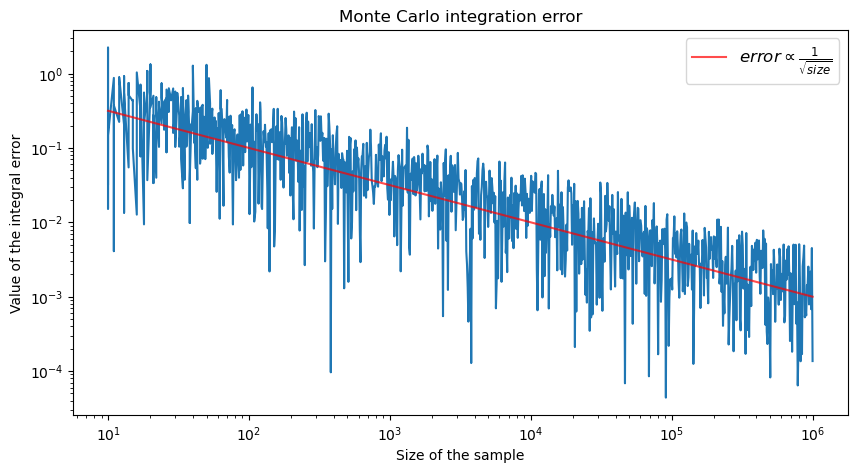

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(np.logspace(1, 6, 1000, dtype=int), vec_error)
plt.plot(np.logspace(1, 6, 1000, dtype=int), np.logspace(1, 6, 1000, dtype=int)**-0.5, "-r", alpha=0.7, label=r"$error \propto \frac{1}{\sqrt{size}}$")
plt.title("Monte Carlo integration error")
plt.xlabel("Size of the sample")
plt.ylabel("Value of the integral error")
plt.loglog()
plt.legend(fontsize=12)
plt.show()

In [10]:
vec_result = []
vec_error = []
for round in range(10000):
    sample = np.random.normal(mu, sigma, 100000)
    montecarlo = np.mean(f(np.abs(sample)))
    result = N*montecarlo
    vec_result.append(result)
    vec_error.append(np.abs(result-known_result)/known_result)

In [11]:
mean = np.mean(vec_result)
std = np.std(vec_result, ddof=1)
x = np.linspace(mean-3*std, mean+3*std, 1000)

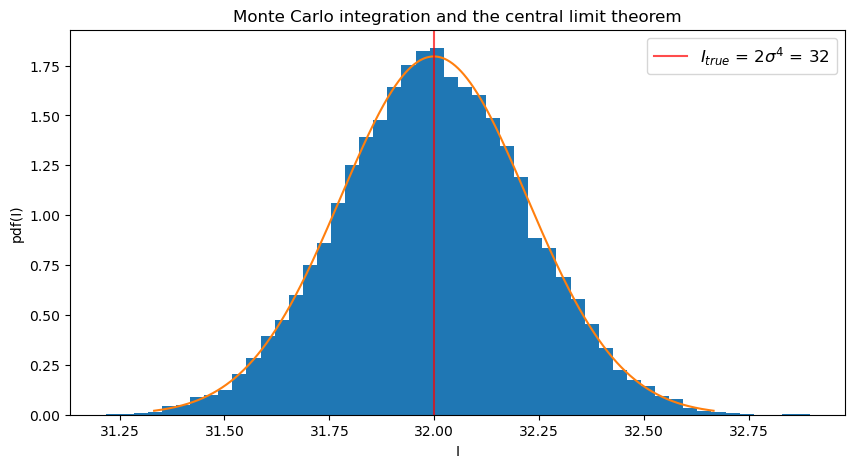

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(vec_result, bins=50, density=True)
plt.plot(x, norm.pdf(x, mean, std))
plt.axvline(x=known_result, color='red', alpha=0.7, label="$I_{true}$ = $2 \sigma ^4$ = 32")
plt.title("Monte Carlo integration and the central limit theorem")
plt.xlabel("I")
plt.ylabel("pdf(I)")
plt.legend(fontsize=12)
plt.show()